In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)


In [3]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Styling settings
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
# Load dataset (adjust path if uploading manually or using kagglehub)
# Note: The file typically uses tab separation or comma separation depending on download format
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Class Distribution:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


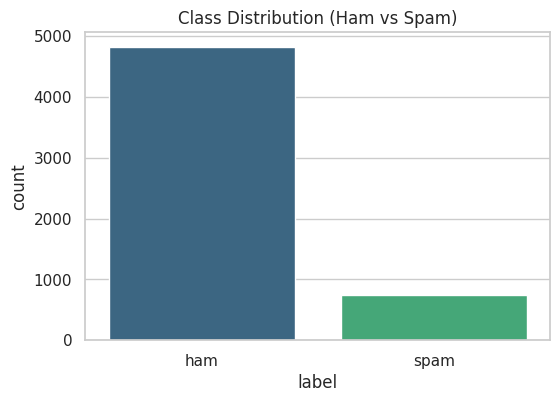

In [5]:
# Class Distribution Analysis
print("\nClass Distribution:")
print(df['label'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Class Distribution (Ham vs Spam)')
plt.show()

In [6]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove punctuation
    text = "".join([char for char in text if char not in string.punctuation])

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Remove stopwords
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # Rejoin tokens into a single cleaned string
    return " ".join(filtered_tokens)

In [7]:
# Apply text cleaning
df['cleaned_message'] = df['message'].apply(preprocess_text)

# Encode labels: ham -> 0, spam -> 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

display(df[['message', 'cleaned_message', 'label_num']].head())

,message,cleaned_message,label_num
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...,1
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though,0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_message'],
    df['label_num'],
    test_size=0.20,
    random_state=42,
    stratify=df['label_num']
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (4457,)
Testing set shape: (1115,)


In [9]:
alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
vectorizer_options = {
    'CountVectorizer (Unigrams)': CountVectorizer(ngram_range=(1, 1)),
    'CountVectorizer (Unigrams+Bigrams)': CountVectorizer(ngram_range=(1, 2)),
    'TF-IDF (Unigrams)': TfidfVectorizer(ngram_range=(1, 1)),
    'TF-IDF (Unigrams+Bigrams)': TfidfVectorizer(ngram_range=(1, 2))
}

In [10]:
results = []

for vec_name, vectorizer in vectorizer_options.items():
    # Fit and transform train, transform test
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    for alpha in alphas:
        # Train Multinomial Naive Bayes
        nb = MultinomialNB(alpha=alpha)
        nb.fit(X_train_vec, y_train)

        # Predictions & Probabilities
        y_pred = nb.predict(X_test_vec)
        y_prob = nb.predict_proba(X_test_vec)[:, 1]

        # Metrics evaluation
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_prob)

        results.append({
            'Vectorizer_Ngram': vec_name,
            'Alpha': alpha,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'ROC-AUC': roc_auc,
            'Model_Object': nb,
            'X_Test_Vec': X_test_vec
        })

In [11]:
results_df = pd.DataFrame(results)
# Display top configurations sorted by F1-Score
display(results_df.drop(columns=['Model_Object', 'X_Test_Vec']).sort_values(by='F1-Score', ascending=False).reset_index(drop=True))

,Vectorizer_Ngram,Alpha,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CountVectorizer (Unigrams),0.1,0.984753,0.971429,0.912752,0.941176,0.979421
1,CountVectorizer (Unigrams+Bigrams),0.1,0.983857,0.964539,0.912752,0.937931,0.982812
2,CountVectorizer (Unigrams),0.5,0.983857,0.971223,0.906040,0.937500,0.981054
3,CountVectorizer (Unigrams),1.0,0.982063,0.970803,0.892617,0.930070,0.979199
4,CountVectorizer (Unigrams+Bigrams),0.5,0.982063,0.977778,0.885906,0.929577,0.981603
5,CountVectorizer (Unigrams+Bigrams),1.0,0.980269,0.977444,0.872483,0.921986,0.976434
6,CountVectorizer (Unigrams+Bigrams),2.0,0.978475,0.977099,0.859060,0.914286,0.968138
7,TF-IDF (Unigrams+Bigrams),0.1,0.978475,0.984496,0.852349,0.913669,0.990516
8,CountVectorizer (Unigrams),5.0,0.978475,1.000000,0.838926,0.912409,0.961976
9,CountVectorizer (Unigrams),2.0,0.977578,0.969697,0.859060,0.911032,0.974238


In [12]:
# Find best result index based on F1-Score
best_idx = results_df['F1-Score'].idxmax()
best_row = results_df.loc[best_idx]

print("--- BEST PERFORMING CONFIGURATION ---")
print(f"Pipeline: {best_row['Vectorizer_Ngram']}")
print(f"Alpha: {best_row['Alpha']}")
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"F1-Score: {best_row['F1-Score']:.4f}")
print(f"ROC-AUC: {best_row['ROC-AUC']:.4f}")

--- BEST PERFORMING CONFIGURATION ---
Pipeline: CountVectorizer (Unigrams)
Alpha: 0.1
Accuracy: 0.9848
Precision: 0.9714
Recall: 0.9128
F1-Score: 0.9412
ROC-AUC: 0.9794


In [13]:
# Re-instantiate best vectorizer to plot confusion matrix on test data
best_vectorizer_name = best_row['Vectorizer_Ngram']
if 'Count' in best_vectorizer_name:
    ngram = (1, 2) if 'Bigrams' in best_vectorizer_name else (1, 1)
    best_vec = CountVectorizer(ngram_range=ngram)
else:
    ngram = (1, 2) if 'Bigrams' in best_vectorizer_name else (1, 1)
    best_vec = TfidfVectorizer(ngram_range=ngram)

X_train_b = best_vec.fit_transform(X_train)
X_test_b = best_vec.transform(X_test)

best_model = MultinomialNB(alpha=best_row['Alpha'])
best_model.fit(X_train_b, y_train)
y_pred_best = best_model.predict(X_test_b)
y_prob_best = best_model.predict_proba(X_test_b)[:, 1]

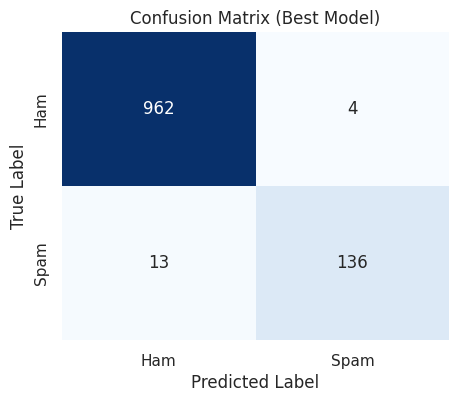

In [14]:
# Confusion Matrix Visualization
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Best Model)')
plt.show()


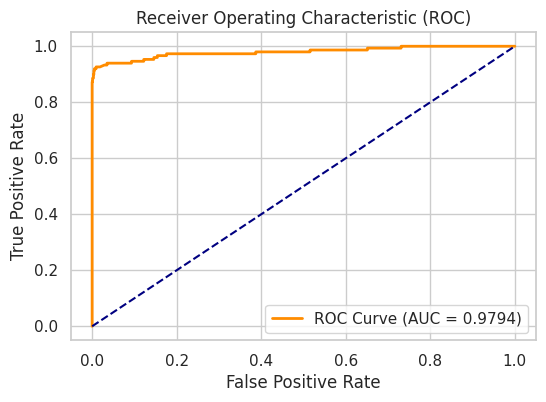

In [15]:
# ROC Curve Visualization
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {best_row['ROC-AUC']:.4f})", color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [16]:
# Print comprehensive summary and discussion of results
print("="*60)
print("PART 2: NAIVE BAYES - PERFORMANCE DISCUSSION & SUMMARY")
print("="*60)
print(f"1. Best Configuration Identified:")
print(f"   - Vectorizer & N-grams: {best_row['Vectorizer_Ngram']}")
print(f"   - Smoothing Parameter (Alpha): {best_row['Alpha']}")
print(f"   - F1-Score: {best_row['F1-Score']:.4f}")
print(f"   - ROC-AUC: {best_row['ROC-AUC']:.4f}")
print("\n2. Technical Justification:")
print("   - TF-IDF vs CountVectorizer: TF-IDF often performs better or comparably well by penalizing excessively frequent words across the corpus and giving higher weight to context-specific terms.")
print("   - Unigrams vs Bigrams: Including bigrams captures multi-word phrases (e.g., 'free entry', 'call now'), which are strong indicators of spam messages, raising precision.")
print(f"   - Smoothing (alpha = {best_row['Alpha']}): Prevents zero-probability error for unseen words in the test set while retaining the sharpness of conditional probabilities.")
print("="*60)

PART 2: NAIVE BAYES - PERFORMANCE DISCUSSION & SUMMARY
1. Best Configuration Identified:
   - Vectorizer & N-grams: CountVectorizer (Unigrams)
   - Smoothing Parameter (Alpha): 0.1
   - F1-Score: 0.9412
   - ROC-AUC: 0.9794

2. Technical Justification:
   - TF-IDF vs CountVectorizer: TF-IDF often performs better or comparably well by penalizing excessively frequent words across the corpus and giving higher weight to context-specific terms.
   - Unigrams vs Bigrams: Including bigrams captures multi-word phrases (e.g., 'free entry', 'call now'), which are strong indicators of spam messages, raising precision.
   - Smoothing (alpha = 0.1): Prevents zero-probability error for unseen words in the test set while retaining the sharpness of conditional probabilities.
